In [20]:
!gdown --folder "https://drive.google.com/drive/folders/19SrhC6DD8azU_aVUKdeTVf8mAOIcTTJ1"
!gdown --folder "https://drive.google.com/drive/u/2/folders/1OL2Xjf2CfbNvcjhmal86QUIhl_8OSs-4"
!ls

Retrieving folder contents
Processing file 1-CT_4_HST6uN0f2IZUe5VaL2KA9chOCV DSC01586.JPG
Processing file 1-DwDYVM8Eu_3dBw84cK5kDCqH7cbx29M DSC01587.JPG
Processing file 1-Lk_Ypvrp3vN4XbWFIYmf-pJnErzkfEl DSC01588.JPG
Processing file 1-AZcinB0NAEVKEZ_kE-AjJ3ffhDZJgQk DSC01589.JPG
Processing file 1-9Ehf4MlqCyDXoVBG8GK19GzUoSwV5vG DSC01590.JPG
Processing file 1-2PqEVN2ucXaKpRrp1DFrXUdxNEaHVc0 DSC01592.JPG
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1-CT_4_HST6uN0f2IZUe5VaL2KA9chOCV
To: /kaggle/working/may anh khanh trinh 24mp/DSC01586.JPG
100%|██████████████████████████████████████| 12.8M/12.8M [00:00<00:00, 52.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-DwDYVM8Eu_3dBw84cK5kDCqH7cbx29M
To: /kaggle/working/may anh khanh trinh 24mp/DSC01587.JPG
100%|███████████████████████████████████████| 12.7M/12.7M [00:00<00:00, 123MB/s]
Downloading...
From: https://drive.googl

In [21]:
import os
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as T
from sklearn.metrics.pairwise import cosine_similarity

device = "cuda" if torch.cuda.is_available() else "cpu"

model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
model.eval().to(device)



Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affi

In [22]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

def normalize(v):
    return v / np.linalg.norm(v)

def get_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model(img)

    emb = emb.squeeze().cpu().numpy()
    return normalize(emb)

In [23]:
import os

folder = "/kaggle/working/may anh khanh trinh 24mp"

class_embeddings = {}
class_path = {}

for file in os.listdir(folder):
    path = os.path.join(folder, file)

    if file.lower().endswith((".jpg", ".png", ".jpeg")):
        label = file.split(".")[0]  # use filename as class
        class_path[label] = path
        class_embeddings[label] = get_embedding(path)

print("Loaded:", class_embeddings.keys())



Loaded: dict_keys(['DSC01588', 'DSC01592', 'DSC01589', 'DSC01586', 'DSC01587', 'DSC01590'])


In [28]:
def classify(query_path):
    query_emb = get_embedding(query_path)

    best_label = None
    best_score = -1

    for label, emb in class_embeddings.items():
        score = cosine_similarity([query_emb], [emb])[0][0]

        if score > best_score:
            best_score = score
            best_label = label

    return best_label, best_score

  0%|          | 0/8 [00:00<?, ?it/s]

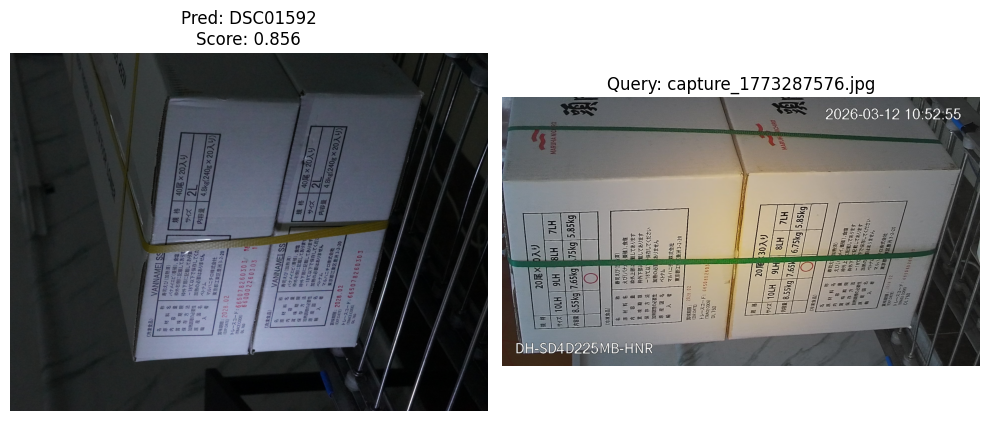

 12%|█▎        | 1/8 [00:03<00:26,  3.78s/it]

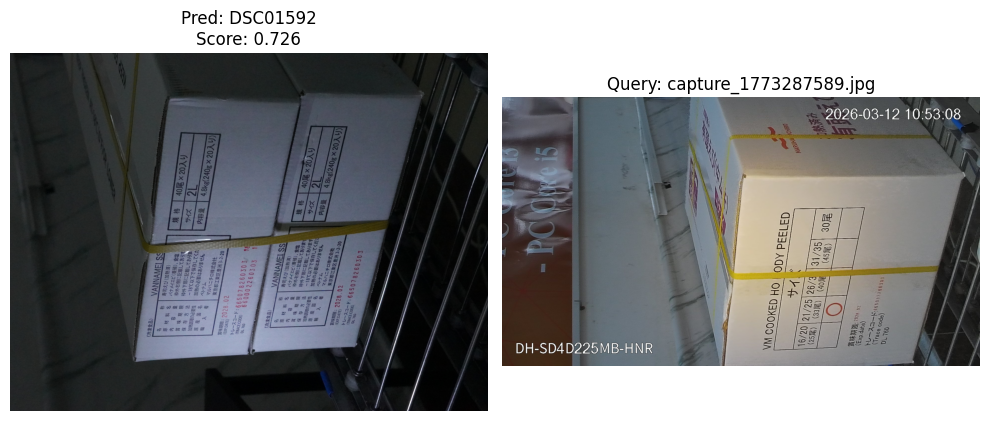

 25%|██▌       | 2/8 [00:07<00:22,  3.80s/it]

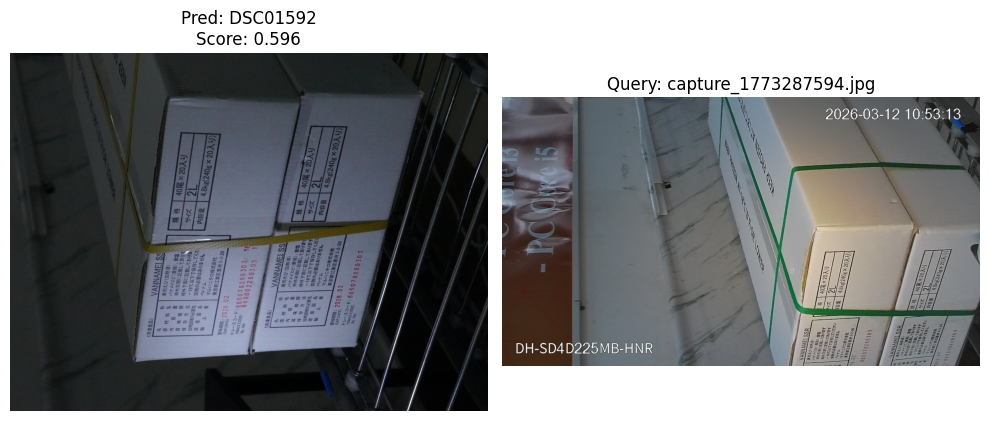

 38%|███▊      | 3/8 [00:11<00:18,  3.78s/it]

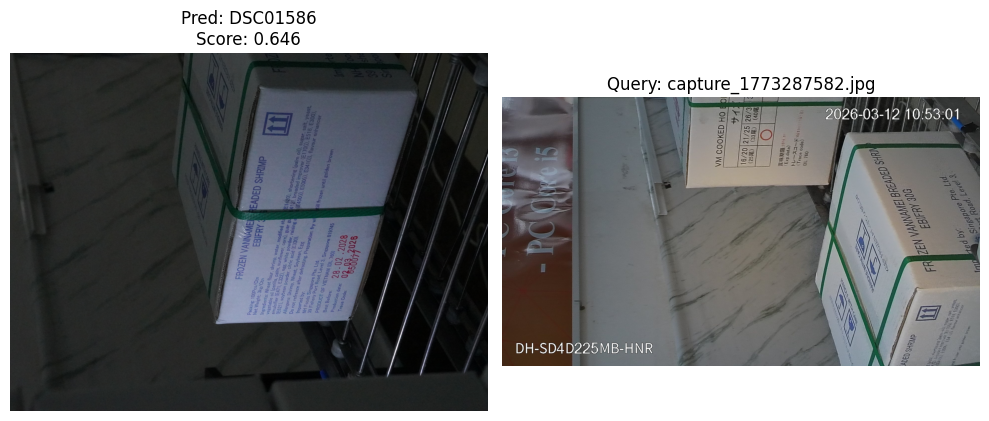

 50%|█████     | 4/8 [00:15<00:15,  3.79s/it]

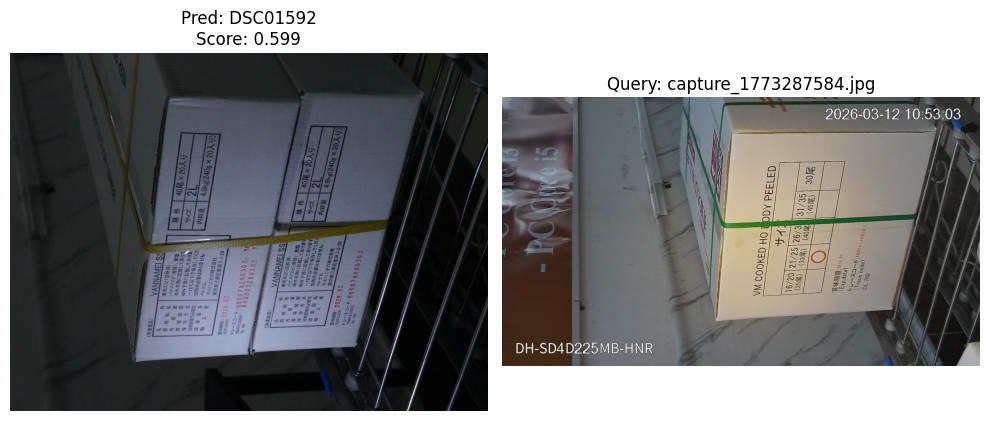

 62%|██████▎   | 5/8 [00:18<00:11,  3.79s/it]

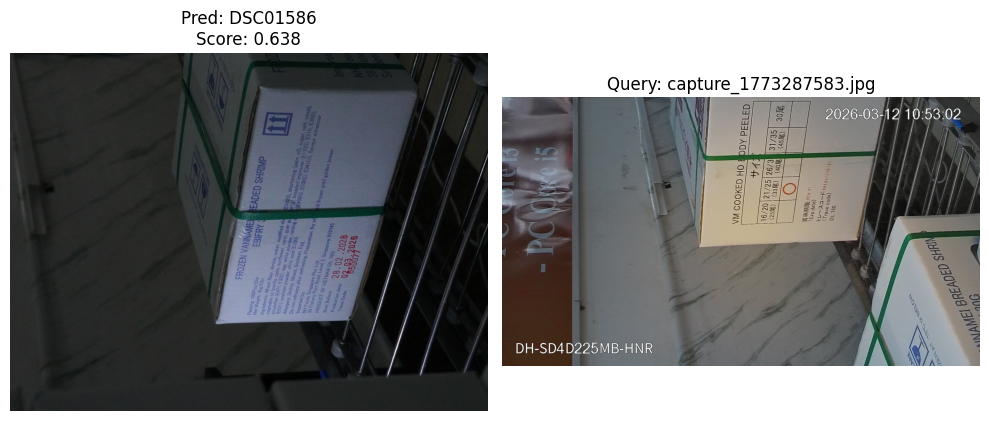

 75%|███████▌  | 6/8 [00:22<00:07,  3.77s/it]

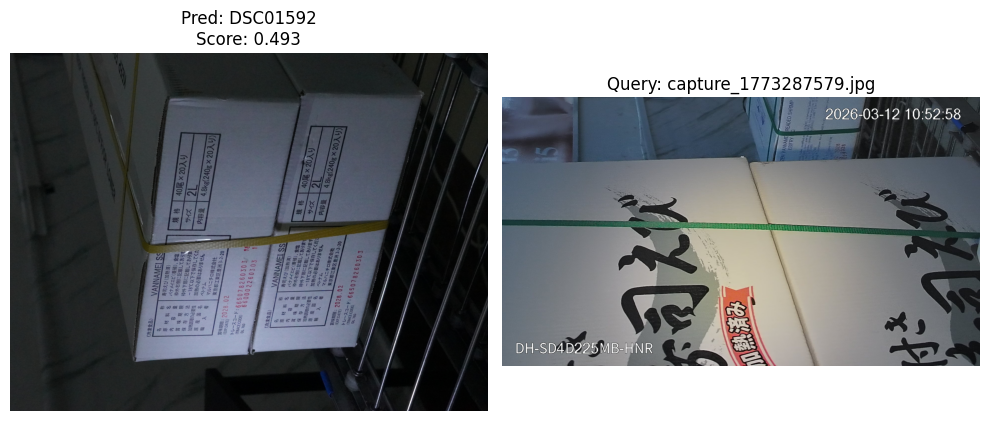

 88%|████████▊ | 7/8 [00:26<00:03,  3.78s/it]

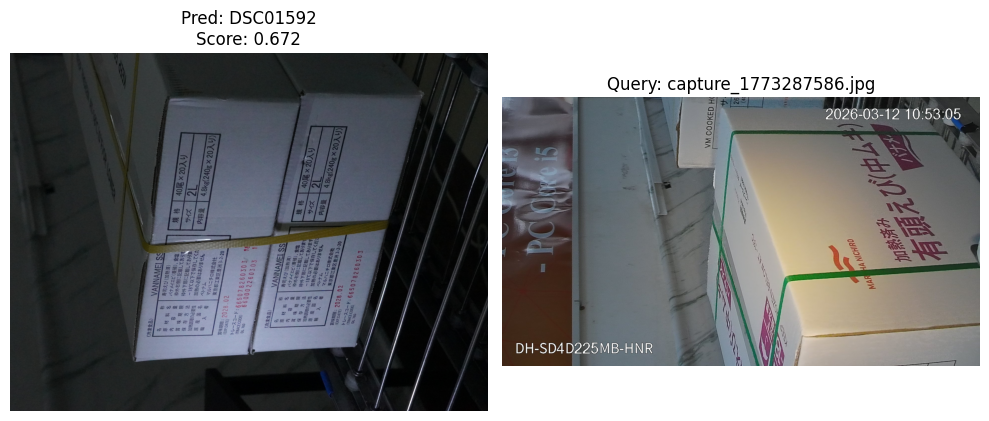

100%|██████████| 8/8 [00:30<00:00,  3.78s/it]


In [30]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import  tqdm

query_folder = "/kaggle/working/12_03_2026 snapshot"

for file in tqdm(os.listdir(query_folder)):
    if not file.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    query_path = os.path.join(query_folder, file)

    # ---- predict ----
    label, score = classify(query_path)

    # ---- load images ----
    img1_path = class_path[label]
    img1 = Image.open(img1_path)
    img2 = Image.open(query_path)

    # ---- plot ----
    plt.figure(figsize=(10, 5))

    # predicted class
    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(f"Pred: {label}\nScore: {score:.3f}")
    plt.axis("off")

    # query image
    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(f"Query: {file}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
    